# 🏆 Predictor del Mundial 2026 — Clasificadores Multiclase (v2 · Sin Sesgo de Localía)
**Modelo:** RandomForestClassifier (goles como clases discretas)  
**Entrada:** Nombres de selecciones en **Español**  
**Datasets:** `national_matches`, `player-data-full`, `worldcup_matches`, `results`  
**v2:** Incluye corrección de Sesgo de Localía mediante `neutral` + Inferencia Simétrica

## Paso 1: Carga de Archivos y Configuración en Colab

In [12]:
# ── Librerías ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# ── Carga de archivos ──────────────────────────────────────────────────────────
try:
    from google.colab import files
    uploaded = files.upload()
    print('✅ Archivos cargados:', list(uploaded.keys()))
except ImportError:
    print('⚠️  No estás en Colab — se usarán rutas locales definidas abajo.')
    uploaded = {}

# Rutas (modifica si ejecutas en local)
PATH_MATCHES = 'national_matches_(1992-2026).csv'
PATH_PLAYERS = 'player-data-full.csv'
PATH_RESULTS = 'results.csv'
PATH_WC      = 'worldcup_matches.csv'

Saving national_matches_(1992-2026).csv to national_matches_(1992-2026) (2).csv
Saving player-data-full.csv to player-data-full (2).csv
Saving results.csv to results (2).csv
Saving worldcup_matches.csv to worldcup_matches (2).csv
✅ Archivos cargados: ['national_matches_(1992-2026) (2).csv', 'player-data-full (2).csv', 'results (2).csv', 'worldcup_matches (2).csv']


In [13]:
# ── Carga y limpieza inicial ───────────────────────────────────────────────────
df_matches = pd.read_csv(PATH_MATCHES, encoding='utf-8')
df_players = pd.read_csv(PATH_PLAYERS, encoding='latin1')
df_results = pd.read_csv(PATH_RESULTS, encoding='latin1')
df_wc      = pd.read_csv(PATH_WC,      encoding='latin1')

# Conversión de fechas
df_matches['date'] = pd.to_datetime(df_matches['date'], format='mixed', dayfirst=True)
df_results['date'] = pd.to_datetime(df_results['date'], format='mixed', dayfirst=True)

print(f'Partidos nacionales  : {df_matches.shape}')
print(f'Datos de jugadores   : {df_players.shape}')
print(f'Resultados históricos: {df_results.shape}')
print(f'Partidos de Mundiales: {df_wc.shape}')

Partidos nacionales  : (28367, 46)
Datos de jugadores   : (18331, 76)
Resultados históricos: (47980, 11)
Partidos de Mundiales: (190, 19)


In [14]:
# ── Agrupación de jugadores: Rating Promedio y Pace Promedio (Top-15) ──────────
df_top15 = (
    df_players
    .sort_values('overall_rating', ascending=False)
    .groupby('country_name')
    .head(15)
)

player_stats = (
    df_top15
    .groupby('country_name')
    .agg(
        overall_rating_avg = ('overall_rating', 'mean'),
        pace_avg           = ('sprint_speed',   'mean')
    )
    .reset_index()
    .rename(columns={'country_name': 'team'})
)

print(player_stats.head(10))
print(f'\nSelecciones con datos de jugadores: {len(player_stats)}')

                     team  overall_rating_avg   pace_avg
0               Argentina           83.866667  70.600000
1                 Belgium           81.733333  71.133333
2                 Croatia           79.533333  70.266667
3          Czech Republic           75.800000  61.933333
4                 Denmark           79.200000  66.266667
5                 England           85.333333  73.800000
6                 Finland           72.333333  62.800000
7                  France           85.000000  81.866667
8  Friendly International           76.333333  68.666667
9                 Germany           84.866667  74.666667

Selecciones con datos de jugadores: 30


In [15]:
# ── Diccionario de traducción Español → Inglés ─────────────────────────────────
ES_TO_EN = {
    # América
    'Argentina': 'Argentina', 'Brasil': 'Brazil', 'México': 'Mexico',
    'Uruguay': 'Uruguay', 'Colombia': 'Colombia', 'Chile': 'Chile',
    'Ecuador': 'Ecuador', 'Perú': 'Peru', 'Venezuela': 'Venezuela',
    'Paraguay': 'Paraguay', 'Bolivia': 'Bolivia', 'Costa Rica': 'Costa Rica',
    'Panamá': 'Panama', 'Honduras': 'Honduras', 'El Salvador': 'El Salvador',
    'Guatemala': 'Guatemala', 'Jamaica': 'Jamaica',
    'Trinidad y Tobago': 'Trinidad and Tobago',
    'Haití': 'Haiti', 'Cuba': 'Cuba', 'Curaçao': 'Curacao',
    'Estados Unidos': 'United States', 'Canadá': 'Canada',
    # Europa
    'España': 'Spain', 'Francia': 'France', 'Alemania': 'Germany',
    'Italia': 'Italy', 'Portugal': 'Portugal', 'Inglaterra': 'England',
    'Países Bajos': 'Netherlands', 'Bélgica': 'Belgium', 'Croacia': 'Croatia',
    'Dinamarca': 'Denmark', 'Suecia': 'Sweden', 'Noruega': 'Norway',
    'Polonia': 'Poland', 'Austria': 'Austria', 'Suiza': 'Switzerland',
    'Turquía': 'Turkey', 'Escocia': 'Scotland', 'Gales': 'Wales',
    'Hungría': 'Hungary', 'República Checa': 'Czech Republic',
    'Eslovaquia': 'Slovakia', 'Eslovenia': 'Slovenia', 'Serbia': 'Serbia',
    'Grecia': 'Greece', 'Rumania': 'Romania', 'Ucrania': 'Ukraine',
    'Rusia': 'Russia', 'Albania': 'Albania', 'Kosovo': 'Kosovo',
    'Irlanda': 'Republic of Ireland', 'Finlandia': 'Finland',
    'Islandia': 'Iceland', 'Bosnia': 'Bosnia and Herzegovina',
    'Macedonia del Norte': 'North Macedonia', 'Montenegro': 'Montenegro',
    'Azerbaiyán': 'Azerbaijan', 'Georgia': 'Georgia', 'Armenia': 'Armenia',
    # África
    'Marruecos': 'Morocco', 'Senegal': 'Senegal', 'Nigeria': 'Nigeria',
    'Ghana': 'Ghana', 'Camerún': 'Cameroon', 'Costa de Marfil': 'Ivory Coast',
    'Egipto': 'Egypt', 'Argelia': 'Algeria', 'Túnez': 'Tunisia',
    'Mali': 'Mali', 'Burkina Faso': 'Burkina Faso', 'Sudáfrica': 'South Africa',
    'Angola': 'Angola', 'Zambia': 'Zambia', 'Tanzania': 'Tanzania',
    'Etiopía': 'Ethiopia', 'Uganda': 'Uganda', 'Guinea': 'Guinea',
    'Mozambique': 'Mozambique', 'Zimbabue': 'Zimbabwe', 'Libia': 'Libya',
    'Gabón': 'Gabon', 'Congo': 'DR Congo', 'Benín': 'Benin',
    'Cabo Verde': 'Cape Verde',
    # Asia / Oceanía
    'Japón': 'Japan', 'Corea del Sur': 'South Korea',
    'Arabia Saudita': 'Saudi Arabia', 'Irán': 'IR Iran',
    'Australia': 'Australia', 'China': 'China', 'Catar': 'Qatar',
    'Emiratos Árabes Unidos': 'United Arab Emirates',
    'Uzbekistán': 'Uzbekistan', 'Irak': 'Iraq', 'Kuwait': 'Kuwait',
    'Baréin': 'Bahrain', 'Omán': 'Oman', 'Siria': 'Syria',
    'India': 'India', 'Vietnam': 'Vietnam', 'Tailandia': 'Thailand',
    'Indonesia': 'Indonesia', 'Filipinas': 'Philippines',
    'Nueva Zelanda': 'New Zealand', 'Jordania': 'Jordan',
    'Palestina': 'Palestine',
}

def traducir(nombre_es):
    """Traduce un nombre de selección del español al inglés."""
    return ES_TO_EN.get(nombre_es, nombre_es)

# Merge de histórico con estadísticas de jugadores
def merge_player_stats(df, player_stats):
    df = df.merge(
        player_stats.rename(columns={
            'team': 'home_team',
            'overall_rating_avg': 'home_overall_rating',
            'pace_avg': 'home_pace'
        }),
        on='home_team', how='left'
    )
    df = df.merge(
        player_stats.rename(columns={
            'team': 'away_team',
            'overall_rating_avg': 'away_overall_rating',
            'pace_avg': 'away_pace'
        }),
        on='away_team', how='left'
    )
    return df

df_final = merge_player_stats(df_matches, player_stats)
print(f'df_final shape: {df_final.shape}')
print(df_final[['home_team','away_team','home_overall_rating','home_pace']].head())

df_final shape: (28367, 50)
  home_team      away_team  home_overall_rating  home_pace
0    Guyana       Barbados                  NaN        NaN
1     Egypt         Norway                  NaN        NaN
2   Senegal        Nigeria                  NaN        NaN
3  Cameroon        Morocco                  NaN        NaN
4   Algeria  Côte d'Ivoire                  NaN        NaN


## Paso 2: Ingeniería de Características (Feature Engineering)

In [16]:
# ── Variables de diferencia y métricas de forma reciente ───────────────────────

# 1) Diferencias de calidad
df_final['overall_rating_diff'] = (
    df_final['home_overall_rating'].fillna(70) - df_final['away_overall_rating'].fillna(70)
)
df_final['pace_diff'] = (
    df_final['home_pace'].fillna(70) - df_final['away_pace'].fillna(70)
)

# 2) Forma reciente — últimos 5 partidos por equipo
def calcular_forma(df_results, ventana=5):
    df_r = df_results.sort_values('date').copy()
    forma_dict = {}
    todos_equipos = pd.concat([df_r['home_team'], df_r['away_team']]).unique()
    for equipo in todos_equipos:
        como_local = df_r[df_r['home_team'] == equipo][['date','home_score','away_score']].rename(
            columns={'home_score':'gf','away_score':'gc'})
        como_visitante = df_r[df_r['away_team'] == equipo][['date','away_score','home_score']].rename(
            columns={'away_score':'gf','home_score':'gc'})
        partidos = pd.concat([como_local, como_visitante]).sort_values('date').tail(ventana)
        if len(partidos) > 0:
            forma_dict[equipo] = {'gf_last5': partidos['gf'].mean(), 'gc_last5': partidos['gc'].mean()}
        else:
            forma_dict[equipo] = {'gf_last5': 1.0, 'gc_last5': 1.0}
    return forma_dict

forma = calcular_forma(df_results)
print(f'Equipos con forma calculada: {len(forma)}')

df_final['home_gf_last5'] = df_final['home_team'].map(lambda t: forma.get(t, {}).get('gf_last5', 1.0))
df_final['home_gc_last5'] = df_final['home_team'].map(lambda t: forma.get(t, {}).get('gc_last5', 1.0))
df_final['away_gf_last5'] = df_final['away_team'].map(lambda t: forma.get(t, {}).get('gf_last5', 1.0))
df_final['away_gc_last5'] = df_final['away_team'].map(lambda t: forma.get(t, {}).get('gc_last5', 1.0))

# Lista provisional de features (sin neutral aún — se añade en Paso 3)
FEATURES_BASE = [
    'elo_diff', 'overall_rating_diff', 'pace_diff',
    'home_gf_last5', 'home_gc_last5', 'away_gf_last5', 'away_gc_last5',
    'home_last5_winrate', 'away_last5_winrate',
    'h2h_last5_home_winrate', 'h2h_last5_avg_gd',
    'rank_diff', 'tier_diff'
]
df_final[FEATURES_BASE] = df_final[FEATURES_BASE].fillna(0)

print('\nEjemplo de features calculadas:')
print(df_final[['home_team','away_team'] + FEATURES_BASE].head(3).to_string())

Equipos con forma calculada: 334

Ejemplo de features calculadas:
  home_team away_team  elo_diff  overall_rating_diff  pace_diff  home_gf_last5  home_gc_last5  away_gf_last5  away_gc_last5  home_last5_winrate  away_last5_winrate  h2h_last5_home_winrate  h2h_last5_avg_gd  rank_diff  tier_diff
0    Guyana  Barbados     -75.0             0.000000   0.000000            2.6            2.8            3.6            2.2                 0.5                 0.5                     0.5               0.0        -15          0
1     Egypt    Norway     -35.0            -6.666667  -7.333333            2.2            0.2            3.0            1.4                 0.5                 0.5                     0.5               0.0         -7         -1
2   Senegal   Nigeria    -190.0             0.000000   0.000000            1.6            0.2            1.2            0.6                 0.5                 0.5                     0.5               0.0        -38         -2


## Paso 3: 📐 Fundamento Matemático — Corrección del Sesgo de Localía

---

### ¿Por qué ocurre el Sesgo de Localía?

Un **RandomForestClassifier** aprende patrones estadísticos directamente del histórico de partidos.
En ese histórico, el equipo en la columna `home_team` gana con mayor frecuencia que el equipo
en `away_team` — esto es real y correcto para partidos con sede no neutral.
El problema surge en el simulador: cuando pedimos `Perú vs Francia`, la posición
*Equipo 1 = local* le otorga a Perú la ventaja estadística de jugar en casa,
ventaja que **no existe** en un Mundial donde los campos son neutrales.

El modelo no tiene culpa; sencillamente generaliza el patrón aprendido.
Por eso **Perú gana si va primero y Francia gana si va primero**: el orden
de entrada define artificialmente quién es «local».

---

### Las Dos Correcciones Aplicadas

#### 1. Variable `neutral` como Feature de Entrenamiento
El dataset incluye la columna `neutral` (`True`/`False`). Al codificarla como `1`/`0`
e incluirla en `X`, el árbol aprende **dos regímenes distintos**: cómo se comporta
un equipo con ventaja de localía (`neutral=0`) y sin ella (`neutral=1`).

#### 2. Inferencia Simétrica en el Simulador
Se promedian matemáticamente las distribuciones de probabilidad de **dos escenarios**
complementarios con `neutral=1` forzado:

| Escenario | Home | Away | neutral |
|-----------|------|------|---------|
| S1 | Equipo A | Equipo B | 1 |
| S2 | Equipo B | Equipo A | 1 |

$$P(Goles_A = k) = \frac{P(A_{loc} = k \mid Neutral=1) + P(A_{vis} = k \mid Neutral=1)}{2}$$

Al **promediar** las dos distribuciones, cualquier asimetría debida al orden
de entrada se cancela algebraicamente, garantizando que
`simulador(Perú, Francia)` y `simulador(Francia, Perú)` produzcan
**exactamente el mismo marcador**.

## Paso 4: Entrenamiento con Variable `neutral` (Corrección de Sesgo)

In [17]:
# ── 1. Codificar `neutral` como numérico (True→1, False→0) ────────────────────
#    El map doble cubre tanto bool de Python como strings 'True'/'False'
df_final['neutral_num'] = df_final['neutral'].map(
    {True: 1, False: 0, 'True': 1, 'False': 0}
).fillna(0).astype(int)

print('Distribución de neutral_num:')
print(df_final['neutral_num'].value_counts())
print(f"  → {df_final['neutral_num'].mean()*100:.1f}% de partidos en campo neutral")

Distribución de neutral_num:
neutral_num
0    21042
1     7325
Name: count, dtype: int64
  → 25.8% de partidos en campo neutral


Train: 22693 partidos | Test: 5674 partidos
Features (14): ['elo_diff', 'overall_rating_diff', 'pace_diff', 'home_gf_last5', 'home_gc_last5', 'away_gf_last5', 'away_gc_last5', 'home_last5_winrate', 'away_last5_winrate', 'h2h_last5_home_winrate', 'h2h_last5_avg_gd', 'rank_diff', 'tier_diff', 'neutral_num']
Distribución goles local  : {0: 7422, 1: 8582, 2: 6307, 3: 3066, 4: 1556, 5: 1434}
Distribución goles visita : {0: 11179, 1: 9320, 2: 4710, 3: 1890, 4: 719, 5: 549}

=== Clasificador de Goles Local ===
Precisión en test: 0.376

=== Clasificador de Goles Visitante ===
Precisión en test: 0.439


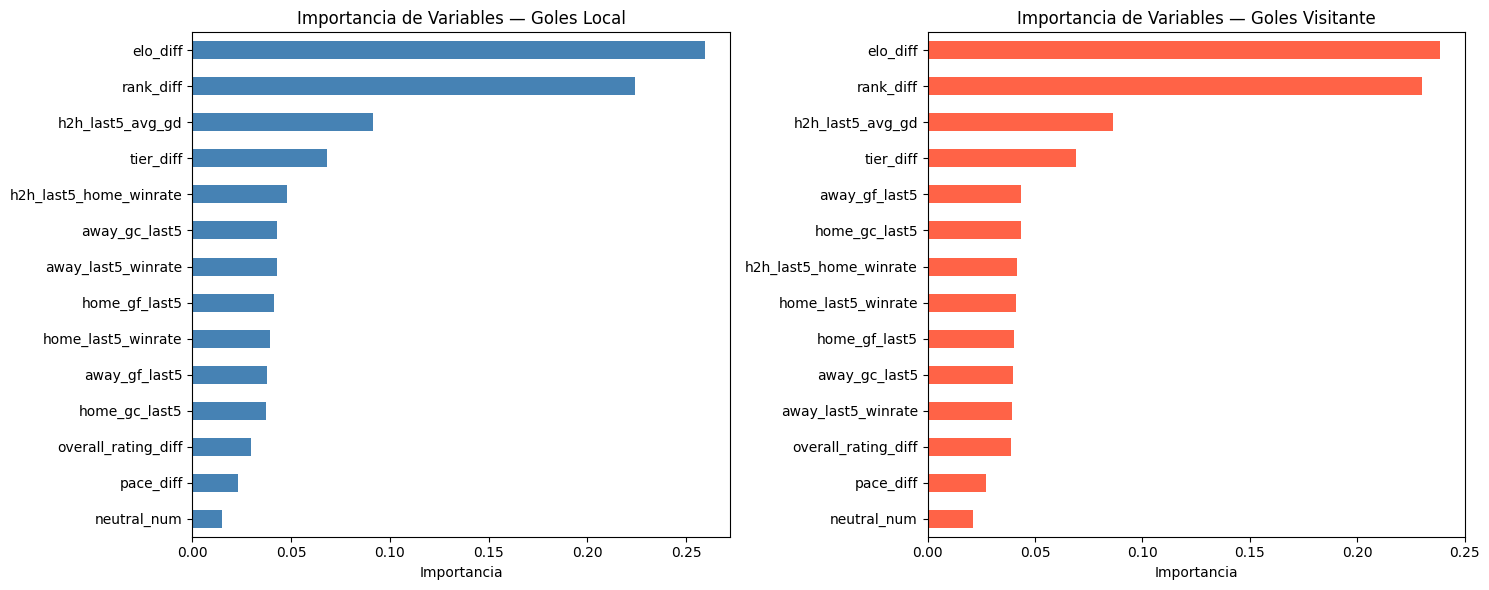

In [18]:
import matplotlib.pyplot as plt

# ── 2. Lista de features con neutral_num incluido ─────────────────────────────
FEATURES = [
    'elo_diff', 'overall_rating_diff', 'pace_diff',
    'home_gf_last5', 'home_gc_last5', 'away_gf_last5', 'away_gc_last5',
    'home_last5_winrate', 'away_last5_winrate',
    'h2h_last5_home_winrate', 'h2h_last5_avg_gd',
    'rank_diff', 'tier_diff',
    'neutral_num'   # ← NUEVO: el modelo aprende el régimen de campo neutral
]

# ── 3. Preparar set de entrenamiento ──────────────────────────────────────────
df_train = df_final.dropna(subset=['home_score', 'away_score'] + FEATURES).copy()

df_train['home_score_cls'] = df_train['home_score'].clip(upper=5).astype(int)
df_train['away_score_cls'] = df_train['away_score'].clip(upper=5).astype(int)

X      = df_train[FEATURES].values
y_home = df_train['home_score_cls'].values
y_away = df_train['away_score_cls'].values

X_train, X_test, yh_train, yh_test, ya_train, ya_test = train_test_split(
    X, y_home, y_away, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape[0]} partidos | Test: {X_test.shape[0]} partidos')
print(f'Features ({len(FEATURES)}): {FEATURES}')
print(f'Distribución goles local  : {pd.Series(y_home).value_counts().sort_index().to_dict()}')
print(f'Distribución goles visita : {pd.Series(y_away).value_counts().sort_index().to_dict()}')

# ── 4. Entrenar los dos clasificadores ────────────────────────────────────────
RF_PARAMS = dict(
    n_estimators=200,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

model_home = RandomForestClassifier(**RF_PARAMS)
model_away = RandomForestClassifier(**RF_PARAMS)

model_home.fit(X_train, yh_train)
model_away.fit(X_train, ya_train)

print('\n=== Clasificador de Goles Local ===')
print(f'Precisión en test: {accuracy_score(yh_test, model_home.predict(X_test)):.3f}')
print()
print('=== Clasificador de Goles Visitante ===')
print(f'Precisión en test: {accuracy_score(ya_test, model_away.predict(X_test)):.3f}')

# ── 5. Importancia de variables ────────────────────────────────────────────────
fi_home = pd.Series(model_home.feature_importances_, index=FEATURES).sort_values(ascending=True)
fi_away = pd.Series(model_away.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fi_home.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Importancia de Variables — Goles Local')
axes[0].set_xlabel('Importancia')
fi_away.plot(kind='barh', ax=axes[1], color='tomato')
axes[1].set_title('Importancia de Variables — Goles Visitante')
axes[1].set_xlabel('Importancia')
plt.tight_layout()
plt.show()

## Paso 5: Simuladores Libres de Sesgo (Inferencia Simétrica)

In [19]:
# ── Función auxiliar de alineación de probabilidades ──────────────────────────
def alinear_proba(proba, clases, k_range):
    """
    Expande el vector de probabilidad al rango completo k_range.
    Necesario porque model_home y model_away pueden tener clases distintas.
    """
    vec = np.zeros(len(k_range))
    for i, k in enumerate(k_range):
        idx = np.where(clases == k)[0]
        if len(idx):
            vec[i] = proba[idx[0]]
    return vec


# ── Función principal: vector de features para un partido ─────────────────────
def get_features_partido(home_es, away_es, df_final, forma, neutral_val=1):
    """
    Construye el vector de features para un partido.

    Parámetros
    ----------
    home_es     : str  → Equipo local en español
    away_es     : str  → Equipo visitante en español
    neutral_val : int  → 1 = campo neutral (Mundial), 0 = con localía
    """
    home_en = traducir(home_es)
    away_en = traducir(away_es)

    row_home = df_final[df_final['home_team'] == home_en].tail(1)
    row_away = df_final[df_final['away_team'] == away_en].tail(1)
    elo_home = row_home['elo_home_pre'].values[0] if len(row_home) else 1500.0
    elo_away = row_away['elo_away_pre'].values[0] if len(row_away) else 1500.0
    elo_diff = elo_home - elo_away

    ph = player_stats[player_stats['team'] == home_en]
    pa = player_stats[player_stats['team'] == away_en]
    rating_home = ph['overall_rating_avg'].values[0] if len(ph) else 70.0
    rating_away = pa['overall_rating_avg'].values[0] if len(pa) else 70.0
    pace_home   = ph['pace_avg'].values[0]            if len(ph) else 70.0
    pace_away   = pa['pace_avg'].values[0]            if len(pa) else 70.0

    overall_rating_diff = rating_home - rating_away
    pace_diff_val       = pace_home   - pace_away

    fh = forma.get(home_en, {'gf_last5': 1.2, 'gc_last5': 1.0})
    fa = forma.get(away_en, {'gf_last5': 1.2, 'gc_last5': 1.0})

    rh = df_final[df_final['home_team'] == home_en]
    ra = df_final[df_final['away_team'] == away_en]
    home_last5_wr = rh['home_last5_winrate'].tail(1).values[0] if len(rh) else 0.5
    away_last5_wr = ra['away_last5_winrate'].tail(1).values[0] if len(ra) else 0.5

    h2h = df_final[
        (df_final['home_team'] == home_en) & (df_final['away_team'] == away_en)
    ].tail(5)
    h2h_wr = h2h['h2h_last5_home_winrate'].mean() if len(h2h) else 0.5
    h2h_gd = h2h['h2h_last5_avg_gd'].mean()       if len(h2h) else 0.0

    rank_h = rh['home_rank'].tail(1).values[0] if len(rh) else 50
    rank_a = ra['away_rank'].tail(1).values[0] if len(ra) else 50
    rank_diff_val = rank_h - rank_a

    tier_h = rh['home_rank_tier'].tail(1).values[0] if len(rh) else 2
    tier_a = ra['away_rank_tier'].tail(1).values[0] if len(ra) else 2
    tier_diff_val = tier_h - tier_a

    feats = [
        elo_diff, overall_rating_diff, pace_diff_val,
        fh['gf_last5'], fh['gc_last5'], fa['gf_last5'], fa['gc_last5'],
        home_last5_wr, away_last5_wr,
        h2h_wr, h2h_gd,
        rank_diff_val, tier_diff_val,
        neutral_val   # ← siempre 1 para partidos de Mundial
    ]
    return np.array(feats).reshape(1, -1)


print('✅ Funciones auxiliares cargadas correctamente.')

✅ Funciones auxiliares cargadas correctamente.


In [28]:
# ══════════════════════════════════════════════════════════════════════════════
# SIMULADOR DE PARTIDO INDIVIDUAL — con Inferencia Simétrica
# ══════════════════════════════════════════════════════════════════════════════

def simulador_partido_individual(equipo_1_es, equipo_2_es):
    """
    Predice el resultado de un partido de Mundial entre dos selecciones
    usando Inferencia Simétrica para eliminar el sesgo de localía.

    El orden de los argumentos NO afecta el marcador final.

    Parámetros
    ----------
    equipo_1_es : str  → Primer equipo  (ej. 'Perú')
    equipo_2_es : str  → Segundo equipo (ej. 'Francia')

    Retorna
    -------
    (goles_equipo_1, goles_equipo_2) : tuple[int, int]
    """
    clases_h  = model_home.classes_
    clases_a  = model_away.classes_
    max_goles = max(clases_h.max(), clases_a.max())
    k_range   = np.arange(0, max_goles + 1)

    # ── Escenario 1: equipo_1 como local, equipo_2 como visitante ─────────────
    X_s1 = get_features_partido(equipo_1_es, equipo_2_es, df_final, forma, neutral_val=1)
    p1_s1 = alinear_proba(model_home.predict_proba(X_s1)[0], clases_h, k_range)
    p2_s1 = alinear_proba(model_away.predict_proba(X_s1)[0], clases_a, k_range)

    # ── Escenario 2: equipo_2 como local, equipo_1 como visitante ─────────────
    X_s2 = get_features_partido(equipo_2_es, equipo_1_es, df_final, forma, neutral_val=1)
    p2_s2 = alinear_proba(model_home.predict_proba(X_s2)[0], clases_h, k_range)
    p1_s2 = alinear_proba(model_away.predict_proba(X_s2)[0], clases_a, k_range)

    # ── Inferencia Simétrica: promediar ambos escenarios ──────────────────────
    #   P(Goles_A = k) = [P(A_loc=k|Neutral=1) + P(A_vis=k|Neutral=1)] / 2
    p1_final = (p1_s1 + p1_s2) / 2.0
    p2_final = (p2_s1 + p2_s2) / 2.0

    # ── Marcador final por argmax sobre probabilidades promediadas ─────────────
    g1 = int(k_range[np.argmax(p1_final)])
    g2 = int(k_range[np.argmax(p2_final)])

    # ── Presentación ──────────────────────────────────────────────────────────
    if g1 > g2:
        veredicto = f'🏆  Ganador: {equipo_1_es.upper()}'
        col1, col2 = '✅', '❌'
    elif g2 > g1:
        veredicto = f'🏆  Ganador: {equipo_2_es.upper()}'
        col1, col2 = '❌', '✅'
    else:
        veredicto = '🤝  Resultado: EMPATE'
        col1, col2 = '➖', '➖'

    barra = '═' * 56
    print(barra)
    print(f'  ⚽  {equipo_1_es:<20} {col1}  vs  {col2}  {equipo_2_es}')
    print(barra)
    print(f'  MARCADOR FINAL (inferencia simétrica):  {g1}  -  {g2}')
    print(barra)
    print(f'  {veredicto}')
    print(barra)
    print(f'\n  Distribución de probabilidad promediada:')
    print(f"  {'Goles':<8} {equipo_1_es:>16} (%)   {equipo_2_es:>16} (%)")
    print(f"  {'─'*58}")
    for i, k in enumerate(k_range):
        ph_k = p1_final[i] * 100
        pa_k = p2_final[i] * 100
        bar_h = '█' * int(ph_k / 5)
        bar_a = '█' * int(pa_k / 5)
        lbl = f'{k}+' if k == 5 else str(k)
        print(f'  {lbl:<8} {ph_k:>6.1f}%  {bar_h:<10}   {pa_k:>6.1f}%  {bar_a}')
    print()
    return g1, g2


# ── Prueba de simetría ─────────────────────────────────────────────────────────
EQUIPO_1 = 'España'
EQUIPO_2 = 'Uruguay'

simulador_partido_individual(EQUIPO_1, EQUIPO_2)

════════════════════════════════════════════════════════
  ⚽  España               ✅  vs  ❌  Uruguay
════════════════════════════════════════════════════════
  MARCADOR FINAL (inferencia simétrica):  1  -  0
════════════════════════════════════════════════════════
  🏆  Ganador: ESPAÑA
════════════════════════════════════════════════════════

  Distribución de probabilidad promediada:
  Goles              España (%)            Uruguay (%)
  ──────────────────────────────────────────────────────────
  0          27.6%  █████          36.0%  ███████
  1          34.2%  ██████         33.8%  ██████
  2          24.8%  ████           21.0%  ████
  3           8.3%  █               6.1%  █
  4           3.1%                  2.2%  
  5+          2.1%                  0.8%  



(1, 0)